# Notebook A — Dynamique de croissance bactérienne

**Notebook A — Stage de lycée · Laboratoire de microbiologie quantitative**

Ce notebook explore comment des règles simples au niveau de la cellule individuelle
produisent les courbes de croissance observées en labo.

---

### Comment utiliser ce notebook
- Exécuter chaque cellule dans l'ordre : **Shift + Entrée**
- Lire les questions encadrées `>` et y réfléchir avant de passer à la suite
- Modifier les paramètres et observer ce qui change

> **Environnement recommandé** : [Google Colab](https://colab.research.google.com) — aucune installation nécessaire.
> En local : `pip install numpy matplotlib pandas`
>
> **Durée estimée** : 4 demi-journées (sections A1–A4)

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
print("Bibliotheques chargees.")

Bibliotheques chargees.


---
## Section A1 — Croissance exponentielle : le modèle déterministe

Une bactérie se divise en deux. Ses deux filles se divisent en deux. Et ainsi de suite.

Si à chaque pas de temps, chaque cellule a une probabilité $p$ de se diviser,
le nombre moyen de nouvelles divisions est $p \times N$.

**Modèle déterministe** : on ignore les fluctuations et on écrit directement :

$$N(t+1) = N(t) \times (1 + p)$$

C'est une **multiplication répétée par le même facteur** $(1+p)$.

> **Avant de coder** : si $N_0 = 10$ et $p = 0.1$, quel est $N$ après 1 pas ?
> Après 2 pas ? Calculez à la main les 3 premières valeurs.

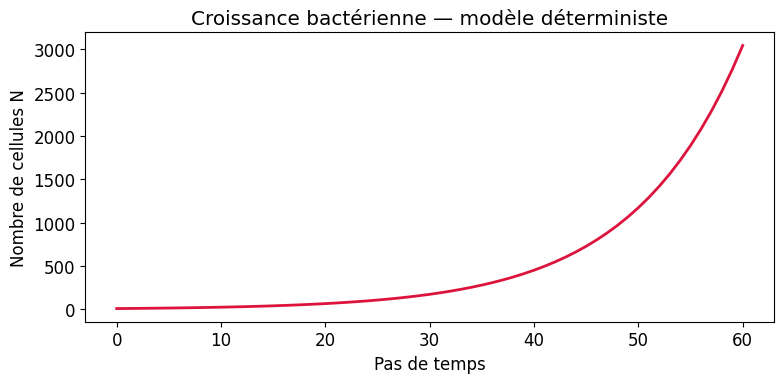

In [2]:
# ── Paramètres ─────────────────────────────────────────────────────────────────
N0      = 10    # nombre initial de cellules
p       = 0.1   # probabilité de division par pas de temps  (doit être << 1)
n_steps = 60    # nombre de pas de temps simulés

# ── Simulation déterministe ─────────────────────────────────────────────────────
N = N0
Ns_det = [N]
for i in range(n_steps):
    N = N * (1 + p)    # multiplication repetee : N(t+1) = N(t) * (1 + p)
    Ns_det.append(N)

# ── Tracé en échelle linéaire ───────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(Ns_det, color='crimson', lw=2)
plt.xlabel("Pas de temps")
plt.ylabel("Nombre de cellules N")
plt.title("Croissance bactérienne — modèle déterministe")
plt.tight_layout()
plt.show()

### Représentation logarithmique

En **échelle logarithmique**, la multiplication répétée par $(1+p)$ se transforme
en une **droite** — ce qui permet d'identifier visuellement la phase de croissance
exponentielle sur vos courbes OD.

Plus la pente est forte, plus les bactéries se divisent vite.


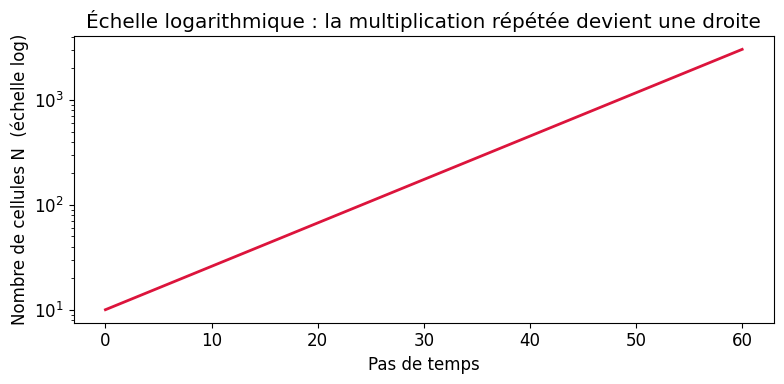

Temps de doublement : 7.3 pas
Valeur finale       : N = 3045 cellules apres 60 pas


In [3]:
# Même courbe en échelle logarithmique
plt.figure(figsize=(8, 4))
plt.plot(Ns_det, color='crimson', lw=2)
plt.yscale('log')
plt.xlabel("Pas de temps")
plt.ylabel("Nombre de cellules N  (échelle log)")
plt.title("Échelle logarithmique : la multiplication répétée devient une droite")
plt.tight_layout()
plt.show()

print(f"Valeur finale : N = {Ns_det[-1]:.0f} cellules apres {n_steps} pas")


### Lien avec le taux de croissance µ

Dans la pratique, l'équation de la croissance exponentielle s'écrit le plus souvent en **temps continu** :

$$N(t) = N_0 \times 2{,}72^{\,\mu t}$$

Ici $\mu t$ peut prendre n'importe quelle valeur réelle (pas seulement des entiers) — c'est une **puissance non entière**. Manipuler ce type de puissance nécessite les fonctions **exponentielle** ($\exp$) et **logarithme** ($\ln$), étudiées en terminale : `np.exp` calcule $2{,}72^x$ pour n'importe quel $x$, et `np.log` fait l'opération inverse.

**Lien avec notre modèle "pas par pas"** $N(t+1)=N(t)\times(1+p)$ : sur un seul pas de temps, le facteur de croissance doit être le même dans les deux écritures, donc

$$(1+p) = 2{,}72^{\,\mu} \quad\Leftrightarrow\quad \mu = \ln(1+p)$$

Pour $p$ petit (disons $p<0{,}1$), l'approximation $\ln(1+p) \approx p$ est valide, donc $\mu \approx p$ : les deux taux sont presque identiques. Pour les valeurs de $p$ plus grandes utilisées dans nos simulations, un petit écart apparaît — c'est normal si le µ mesuré en §A4 ne tombe pas exactement sur le $p$ choisi en §A1.


> **Question — quel est le lien entre la pente de cette droite et le paramètre $p$ ?**
>
> Choisissez deux pas de temps $t_1$ et $t_2$ (par exemple $t_1=0$ et $t_2=5$). À l'aide de `np.log(Ns_det[t1])` et `np.log(Ns_det[t2])`, calculez le **taux d'accroissement** de $\log(N)$ entre ces deux points :
>
> $$\text{pente} = \frac{\log(N(t_2)) - \log(N(t_1))}{t_2 - t_1}$$
>
> (c'est la même formule $\dfrac{\Delta y}{\Delta x}$ que pour une fonction affine — ici appliquée à $\log(N)$ plutôt qu'à $N$.)
>
> Comparez cette valeur à $p$ et à $\ln(1+p)$ (calculé avec `np.log(1+p)`, comme dans la note ci-dessus). Sont-elles égales ? Que pouvez-vous en conclure sur le lien entre la pente et $p$ ?

In [ ]:
# ── Pente de log(N) vs ln(1+p) ──────────────────────────────────────────────────
t1, t2 = 0, 5
pente = (np.log(Ns_det[t2]) - np.log(Ns_det[t1])) / (t2 - t1)
mu_theorique = np.log(1 + p)

print(f"pente                = {pente:.4f}")
print(f"p                    = {p:.4f}")
print(f"mu_theorique=ln(1+p) = {mu_theorique:.4f}")
print()
print(f"écart pente - mu_theorique = {pente - mu_theorique:.2e}  (≈0 : exact)")
print(f"écart p - mu_theorique     = {p - mu_theorique:.4f}  (approximation µ≈p)")


> **Question — calculer le temps de doublement (deux méthodes)**
>
> **Méthode 1 — sans log (comme en §A1)** : à partir de `Ns_det`, repérez le dernier indice $t$ pour lequel $N(t) < 2N_0$ et le premier pour lequel $N(t) \geq 2N_0$. Interpolez linéairement entre ces deux points pour estimer le temps de doublement.
>
> **Méthode 2 — formule formelle (avec log)** : calculez $\mu = \ln(1+p)$, puis
>
> $$t_{1/2} = \frac{\ln 2}{\mu}$$
>
> **Comparez** les deux résultats. Sont-ils cohérents ? Lequel des deux est exact, et lequel est une approximation (et pourquoi) ?

In [ ]:
# ── Temps de doublement : interpolation vs formule ──────────────────────────────
N0_val = Ns_det[0]
t_avant = max(t for t in range(len(Ns_det)) if Ns_det[t] < 2 * N0_val)
t_apres = t_avant + 1
t_double_interp = t_avant + (2*N0_val - Ns_det[t_avant]) / (Ns_det[t_apres] - Ns_det[t_avant])

mu = np.log(1 + p)
t_double_formule = np.log(2) / mu

print(f"Méthode 1 (interpolation) : t_1/2 ≈ {t_double_interp:.3f} pas")
print(f"Méthode 2 (formule ln2/µ) : t_1/2 ≈ {t_double_formule:.3f} pas")
print(f"écart = {abs(t_double_interp - t_double_formule):.3f} pas")


---
## Section A2 — Simulation stochastique : le hasard cellule par cellule

Le modèle déterministe donne la **valeur moyenne attendue**.
Mais en réalité, chaque cellule décide de diviser ou non de façon **aléatoire**.

**Règle microscopique** : à chaque pas de temps, pour *chaque* cellule individuellement,
on tire au sort — elle divise avec probabilité $p$, indépendamment de ses voisines.

> **Question** : si le hasard joue un rôle à chaque cellule,
> pourquoi obtient-on une courbe régulière au niveau de la population ?

On va simuler cela directement et observer ce qui se passe.

---

> ⚠️ **Note technique** : cette simulation suppose $p \ll 1$ (probabilité petite par pas de temps).
> C'est l'approximation dite de *τ-leaping*, version discrète de l'algorithme de Gillespie.
> Pour $p = 0.1$, l'approximation est très bonne.

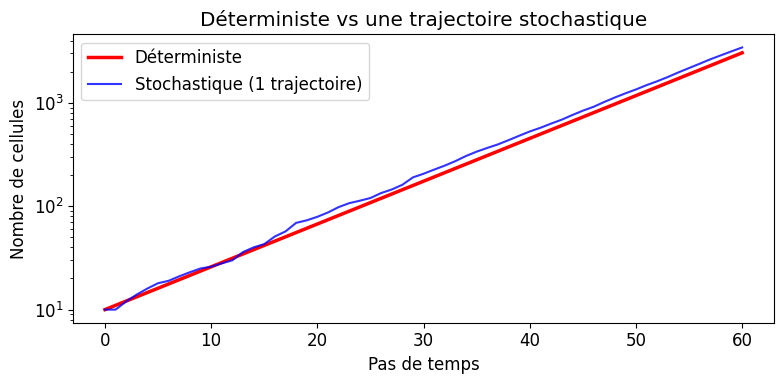

In [37]:
def simulate_one(N0, p, n_steps):
    """Simule une trajectoire stochastique de croissance bactérienne.

    A chaque pas, chaque cellule tire au sort : elle divise (probabilite p) ou non.
    Hypothese : p << 1  (approximation tau-leaping).
    """
    N = N0
    Ns = [N]
    for _ in range(n_steps):
        # np.random.random(N) génère N tirages uniformes dans [0, 1)
        # La cellule divise si son tirage est inférieur à p
        divisions = np.sum(np.random.random(N) < p)
        N += divisions
        Ns.append(N)
    return Ns

# Tester avec une seule trajectoire
Ns_stoch = simulate_one(N0=10, p=0.1, n_steps=60)

plt.figure(figsize=(8, 4))
plt.plot(Ns_det,   'r-',  lw=2.5, label='Déterministe')
plt.plot(Ns_stoch, 'b-',  alpha=0.8, label='Stochastique (1 trajectoire)')
# plt.yscale('log')
plt.xlabel("Pas de temps")
plt.ylabel("Nombre de cellules")
plt.title("Déterministe vs une trajectoire stochastique")
plt.legend()
plt.tight_layout()
plt.show()

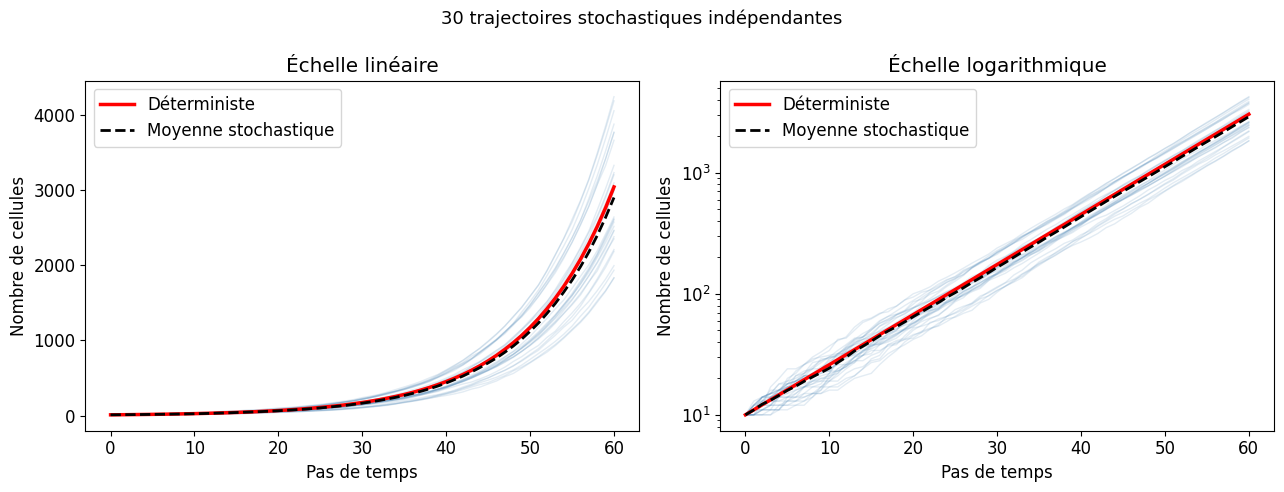

In [40]:
n_traj   = 30
all_traj = []

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for _ in range(n_traj):
    traj = simulate_one(N0=10, p=0.1, n_steps=60)
    all_traj.append(traj)
    for ax in axes:
        ax.plot(traj, alpha=0.15, color='steelblue', lw=1)

mean_traj = np.mean(all_traj, axis=0)

for ax, scale, titre in zip(axes,
                            ['linear', 'log'],
                            ['Échelle linéaire', 'Échelle logarithmique']):
    ax.plot(Ns_det,    'r-',  lw=2.5, label='Déterministe')
    ax.plot(mean_traj, 'k--', lw=2,   label='Moyenne stochastique')
    ax.set_yscale(scale)
    ax.set_xlabel("Pas de temps")
    ax.set_ylabel("Nombre de cellules")
    ax.set_title(titre)
    ax.legend()

plt.suptitle(f"{n_traj} trajectoires stochastiques indépendantes", fontsize=13)
plt.tight_layout()
plt.show()

> **Observation** : chaque trajectoire est différente, mais leur **moyenne** suit
> de près la courbe déterministe. En échelle log, les trajectoires restent
> groupées autour d'une droite.
>
> C'est la **loi des grands nombres** : des règles aléatoires au niveau individuel
> produisent un comportement prévisible au niveau de la population.
>
> **À explorer** : relancez la simulation avec $N_0 = 2$ au lieu de $N_0 = 10$.
> Les trajectoires sont-elles plus ou moins dispersées ? Pourquoi ?

---
## Section A3 — Épuisement des nutriments et phase stationnaire

Dans un milieu fermé (tube, microplaque), les nutriments s'épuisent au fur et à mesure
que les bactéries se multiplient. La croissance finit par s'arrêter.

**Idée** : la probabilité de division $p$ n'est plus constante —
elle dépend de la concentration en nutriments $S$ disponibles.

### La courbe de Monod

$$p(S) = p_{\max} \times \frac{S}{K_S + S}$$

| Situation | Valeur de $p(S)$ | Interprétation |
|-----------|:---------------:|----------------|
| $S \gg K_S$ | $\approx p_{\max}$ | Nutriments abondants → croissance maximale |
| $S = K_S$ | $p_{\max}/2$ | $K_S$ fixe l'échelle de saturation |
| $S \ll K_S$ | $\approx 0$ | Nutriments épuisés → croissance arrêtée |

Cette forme est identique à la cinétique enzymatique de Michaelis-Menten.

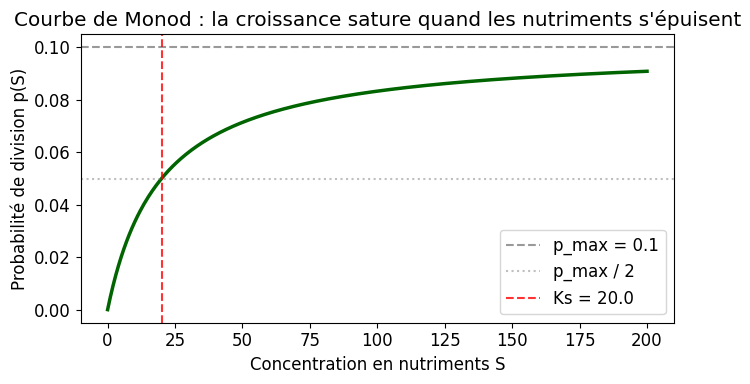

In [41]:
# Visualiser la courbe de Monod avant de l'utiliser dans la simulation
p_max = 0.1     # probabilité de division maximale (nutriments abondants)
Ks    = 20.0    # demi-saturation : S pour lequel p = p_max / 2

S_vals = np.linspace(0, 200, 400)
p_vals = p_max * S_vals / (Ks + S_vals)

plt.figure(figsize=(7, 4))
plt.plot(S_vals, p_vals, color='darkgreen', lw=2.5)
plt.axhline(p_max,     color='gray', linestyle='--', alpha=0.8, label=f'p_max = {p_max}')
plt.axhline(p_max / 2, color='gray', linestyle=':',  alpha=0.5, label='p_max / 2')
plt.axvline(Ks,        color='red',  linestyle='--', alpha=0.8, label=f'Ks = {Ks}')
plt.xlabel("Concentration en nutriments S")
plt.ylabel("Probabilité de division p(S)")
plt.title("Courbe de Monod : la croissance sature quand les nutriments s'épuisent")
plt.legend()
plt.tight_layout()
plt.show()

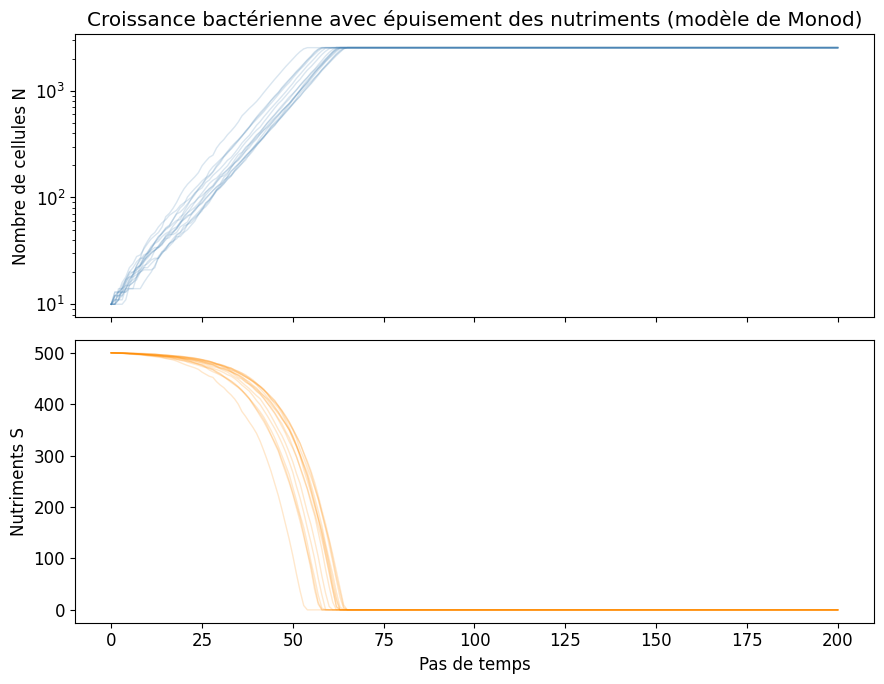

In [42]:
def simulate_nutrients(N0, S0, p_max, Ks, Y, n_steps):
    """Simule la croissance bactérienne avec épuisement des nutriments (modèle de Monod).

    Paramètres
    ----------
    N0     : nombre initial de cellules
    S0     : quantité initiale de nutriments
    p_max  : probabilité de division maximale (nutriments abondants)
    Ks     : demi-saturation (valeur de S pour laquelle p = p_max / 2)
    Y      : rendement (cellules produites par unité de nutriment consommée)
    n_steps: nombre de pas de temps
    """
    N, S = float(N0), float(S0)
    Ns, Ss = [N], [S]
    for _ in range(n_steps):
        p = p_max * S / (Ks + S)                    # Monod : p dépend des nutriments
        divisions = np.sum(np.random.random(int(N)) < p)
        N += divisions
        S -= divisions / Y                           # chaque division consomme 1/Y
        S  = max(S, 0.0)                             # S ne peut pas être négatif
        Ns.append(N)
        Ss.append(S)
    return Ns, Ss

# Paramètres
N0_m, S0_m            = 10, 500
p_max_m, Ks_m, Y_m   = 0.1, 20.0, 5.0
n_m                   = 200

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

for _ in range(15):
    Ns_m, Ss_m = simulate_nutrients(N0_m, S0_m, p_max_m, Ks_m, Y_m, n_m)
    axes[0].plot(Ns_m, alpha=0.2, color='steelblue',  lw=1)
    axes[1].plot(Ss_m, alpha=0.2, color='darkorange', lw=1)

axes[0].set_yscale('log')
axes[0].set_ylabel("Nombre de cellules N")
axes[0].set_title("Croissance bactérienne avec épuisement des nutriments (modèle de Monod)")
axes[1].set_ylabel("Nutriments S")
axes[1].set_xlabel("Pas de temps")
plt.tight_layout()
plt.show()

### Prédiction de la capacité portante

Dans notre modèle, chaque division consomme exactement $1/Y$ unités de nutriments
($Y$ est le **rendement** : nombre de cellules produites par unité de nutriment).

Si on part de $S_0$ nutriments et $N_0$ cellules, quand tous les nutriments sont épuisés :

$$N_{\max} = N_0 + Y \times S_0$$

**Ce n'est pas un paramètre ajusté — c'est une prédiction du modèle.**
La cellule suivante va vérifier cette prédiction numériquement.

In [46]:
# La capacité portante est une PRÉDICTION du modèle, pas un paramètre ajusté
N_max_pred = N0_m + Y_m * S0_m
print(f"Prédiction théorique : N_max = N0 + Y * S0 = {N0_m:.0f} + {Y_m:.0f} * {S0_m:.0f} = {N_max_pred:.0f}")

# Vérification numérique : valeur finale sur 50 simulations indépendantes
N_finals = [simulate_nutrients(N0_m, S0_m, p_max_m, Ks_m, Y_m, n_m)[0][-1]
            for _ in range(50)]
print(f"Valeur simulée     : {np.mean(N_finals):.0f} ± {np.std(N_finals):.0f}  (n = 50 trajectoires)")
print()
print("Ces deux valeurs doivent être proches si le modèle est cohérent !")

Prédiction théorique : N_max = N0 + Y * S0 = 10 + 5 * 500 = 2510
Valeur simulée     : 2533 ± 12  (n = 50 trajectoires)

Ces deux valeurs doivent être proches si le modèle est cohérent !


> **Note** : la simulation donne typiquement ~1 % de plus que la prédiction
> $N_{\max} = N_0 + Y \cdot S_0$. La prédiction suppose une coupure nette
> quand $S = 0$, mais dans le modèle discret $p(S) \to 0$ progressivement —
> quelques divisions ont encore lieu quand $S$ est très petit.
> C'est un écart attendu, pas un bug.

---
## Section A4 — Comparaison avec les données expérimentales

### Premier test : la biomasse produite est-elle proportionnelle au glucose ?

Le modèle de Monod prédit $N_{\max} = N_0 + Y \times S_0$,
soit une relation **linéaire** entre biomasse produite et glucose initial,
avec une droite qui passe par l'origine.

On peut le vérifier directement avec vos données de mardi :
pour chaque tube, on calcule $\Delta\text{OD} = \text{OD}_{\max} - \text{OD}_0$.
Si le modèle est juste, les trois points doivent être alignés sur une droite passant par zéro.

Le **rendement** $Y$ est la pente de cette droite :
combien d'unités OD de bactéries sont produites par gramme de glucose consommé.

  [glucose] = 0.2 g/L  |  delta_OD = 0.145
  [glucose] = 2.0 g/L  |  delta_OD = 1.495
  [glucose] = 4.0 g/L  |  delta_OD = 3.195

Rendement Y estimé par condition :
  [glucose] = 0.2 g/L  ->  Y = 0.725 OD/(g/L)
  [glucose] = 2.0 g/L  ->  Y = 0.748 OD/(g/L)
  [glucose] = 4.0 g/L  ->  Y = 0.799 OD/(g/L)
Moyenne : Y = 0.757 OD/(g/L)


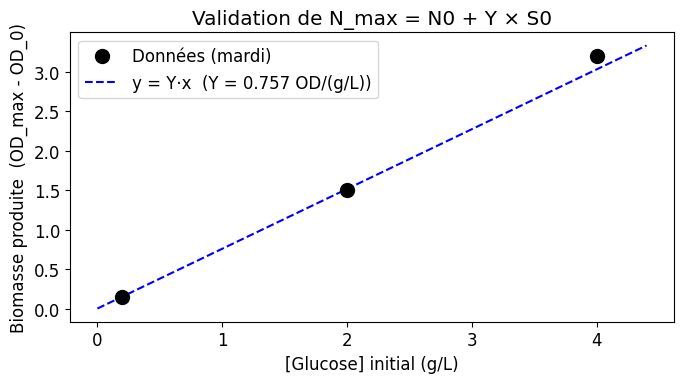


Conversion (1 OD ~ 2e+09 cellules) :
  Y = 0.757 OD/(g/L)  ≈  1.51e+09 cellules/(g/L)

-> Les trois points sont-ils alignés sur la droite ?
   Y est-il à peu près le même pour les 3 concentrations ?
   Si non : quelle hypothèse du modèle est peut-être fausse ?


In [55]:
# ── Entrez vos valeurs mesurées mardi ──────────────────────────────────────────
glucose_gL    = [0.2, 2.0, 4.0]      # concentrations en g/L (0.02%, 0.2%, 0.4%)
OD_initial    = 0.005                # OD au temps 0 (meme pour les 3 tubes)
OD_max_mesure = [0.15, 1.5, 3.2]     # à remplir avec vos valeurs lues sur les courbes

# ── Biomasse produite ──────────────────────────────────────────────────────────
delta_OD = [od - OD_initial for od in OD_max_mesure]

for glu, dod in zip(glucose_gL, delta_OD):
    print(f"  [glucose] = {glu:.1f} g/L  |  delta_OD = {dod:.3f}")

# ── Estimation de Y : pente de chaque point, puis moyenne ─────────────────────
# Chaque point donne une estimation de Y = delta_OD / [glucose]
Y_vals = [dod / glu for dod, glu in zip(delta_OD, glucose_gL)]
Y_fit  = sum(Y_vals) / len(Y_vals)

print(f"\nRendement Y estimé par condition :")
for glu, y in zip(glucose_gL, Y_vals):
    print(f"  [glucose] = {glu:.1f} g/L  ->  Y = {y:.3f} OD/(g/L)")
print(f"Moyenne : Y = {Y_fit:.3f} OD/(g/L)")

# ── Tracé ──────────────────────────────────────────────────────────────────────
glu_dense = np.linspace(0, max(glucose_gL) * 1.1, 100)

plt.figure(figsize=(7, 4))
plt.plot(glucose_gL, delta_OD, 'ko', ms=10, zorder=4, label='Données (mardi)')
plt.plot(glu_dense, [Y_fit * g for g in glu_dense], 'b--', lw=1.5,
         label=f'y = Y·x  (Y = {Y_fit:.3f} OD/(g/L))')
plt.xlabel("[Glucose] initial (g/L)")
plt.ylabel("Biomasse produite  (OD_max - OD_0)")
plt.title("Validation de N_max = N0 + Y × S0")
plt.legend()
plt.tight_layout()
plt.show()

# ── Conversion en cellules ──────────────────────────────────────────────────────
cells_per_OD = 2e9    # ~2×10^9 cellules par unite OD pour E. coli
print(f"\nConversion (1 OD ~ {cells_per_OD:.0e} cellules) :")
print(f"  Y = {Y_fit:.3f} OD/(g/L)  ≈  {Y_fit * cells_per_OD:.2e} cellules/(g/L)")
print()
print("-> Les trois points sont-ils alignés sur la droite ?")
print("   Y est-il à peu près le même pour les 3 concentrations ?")
print("   Si non : quelle hypothèse du modèle est peut-être fausse ?")

### Lecture des données du plate reader
Le plate reader a mesuré l'OD600 de vos cultures toutes les quelques minutes
pendant une nuit entière. On va charger ces données pour
1.  vérifier la biomasse produite en fonction des nutriments pour differentes concentrations de glucose et de lactose.
2. mesurer le taux de croissance dans ces differentes conditions
3. visualiser les courbes de croissance en diauxie.

#### Format du fichier BioTek Gen5

Même format que dans le notebook d'induction : deux blocs TSV (OD + GFP),
avec pour chaque bloc le nom du canal en première ligne.
La fonction `parse_biotek` ci-dessous gère ce format.

> **Note** : si vous avez mesuré des courbes de croissance manuellement (OD au spectro),
> vous pouvez charger un CSV simple avec `pd.read_csv()` :
> colonne `temps_h` (heures) + une colonne par tube.

In [56]:
import pandas as pd

def parse_biotek(filepath):
    # Lit un fichier plate reader BioTek Gen5 (format TSV multi-blocs).
    # Retourne un dict {nom_canal : DataFrame}
    # Chaque DataFrame : colonne 'temps_h' (heures decimales) + colonnes A1...H12.
    with open(filepath, encoding='utf-8', errors='replace') as f:
        lines = f.read().splitlines()
    block_starts = []
    for i, line in enumerate(lines):
        s = line.strip()
        if s and chr(9) not in s and not s[0].isdigit():
            block_starts.append(i)
    result = {}
    for b_idx, b_start in enumerate(block_starts):
        canal_name = lines[b_start].strip()
        if b_start + 2 >= len(lines):
            continue
        header = lines[b_start + 2].strip().split(chr(9))
        b_end = block_starts[b_idx+1] if b_idx+1 < len(block_starts) else len(lines)
        rows = []
        for line in lines[b_start + 3 : b_end]:
            parts = line.strip().split(chr(9))
            if len(parts) < 3:
                continue
            t_str = parts[0]
            if not t_str or t_str == '0:00:00':
                continue
            t_parts = t_str.split(':')
            if len(t_parts) != 3:
                continue
            try:
                h, m, s = int(t_parts[0]), int(t_parts[1]), int(t_parts[2])
            except ValueError:
                continue
            rows.append([h + m/60 + s/3600] + parts[2:])
        if not rows:
            continue
        puits = header[2:]
        n_cols = len(rows[0]) - 1
        cols = ['temps_h'] + puits[:n_cols]
        df = pd.DataFrame(rows, columns=cols)
        for col in df.columns[1:]:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        result[canal_name] = df
    return result


# ══════════════════════════════════════════════════════════════════════════════════
# Pour charger VOS données BioTek, décommentez :
# ══════════════════════════════════════════════════════════════════════════════════
# data  = parse_biotek('votre_diauxie.txt')
# od_df = next(df for name, df in data.items() if '600' in name)
#
# Pour un CSV manuel (temps + une colonne par tube) :
# od_df = pd.read_csv('croissance_manuelle.csv').rename(columns={'temps': 'temps_h'})

# ── Données synthétiques diauxie — À REMPLACER par vos données réelles ─────────
np.random.seed(3)

def generer_diauxie():
    # Simule les courbes BioTek d'une expérience diauxie overnight.
    # Puits A1-A3 : glucose seul (3 concentrations)
    # Puits B1-B2 : glucose + lactose (diauxie)
    # Puits H12   : milieu seul (blanc)
    n_pts = 72
    temps = np.linspace(0, 14, n_pts)

    def logistic(t, K, t_mid, mu):
        return K / (1 + np.exp(-mu * (t - t_mid)))

    od = {'temps_h': temps}
    # Glucose seul : 3 concentrations → 3 capacités portantes différentes
    for label, K in [('A1', 0.35), ('A2', 0.80), ('A3', 1.40)]:
        vals = 0.05 + logistic(temps, K, K*3.8, 1.8)
        od[label] = np.clip(vals + np.random.normal(0, 0.008, n_pts), 0, None)
    # Glucose + Lactose : diauxie (deux phases avec creux intermédiaire)
    for label in ['B1', 'B2']:
        phase1 = logistic(temps, 0.45, 2.5, 2.2)
        # Phase lactose démarre après induction lacZ (~5h de lag total)
        phase2 = np.array([logistic(t, 0.42, 9.0, 1.6) if t > 5.0 else 0.0
                           for t in temps])
        vals = 0.05 + phase1 + phase2
        od[label] = np.clip(vals + np.random.normal(0, 0.010, n_pts), 0, None)
    # Blanc
    od['H12'] = np.clip(0.082 + np.random.normal(0, 0.003, n_pts), 0, None)

    return pd.DataFrame(od)

od_df = generer_diauxie()
print("Donnees chargees.")
print(f"  {len(od_df)} points, {len(od_df.columns)-1} puits")
print(f"  Duree : {od_df['temps_h'].min():.1f} – {od_df['temps_h'].max():.1f} h")
print(od_df[['temps_h', 'A1', 'A2', 'B1', 'H12']].head(3).to_string(index=False))

Donnees chargees.
  72 points, 6 puits
  Duree : 0.0 – 14.0 h
 temps_h       A1       A2       B1      H12
0.000000 0.093580 0.052112 0.062726 0.081981
0.197183 0.093799 0.068923 0.053059 0.086503
0.394366 0.105564 0.060650 0.058268 0.079390


### Relation biomasse / nutriments — vérification sur le plate reader

Le plate reader nous donne l'OD600 de **beaucoup** de conditions simultanément.
On va d'abord tracer toutes les courbes de croissance, extraire l'OD maximale
de chaque puits, puis vérifier que $\Delta\text{OD} \propto [\text{glucose}]$.

On pourra aussi comparer le rendement $Y$ mesuré ici avec celui obtenu mardi
à la main — et l'étendre aux puits **lactose seul** si le layout le permet.

In [ ]:
# ── Layout — ADAPTER à votre plaque réelle ────────────────────────────────────
puits_glu     = ['A1', 'A2', 'A3']   # glucose seul, concentrations croissantes
puits_lac     = []                    # lactose seul (laisser [] si absent)
blanc         = 'H12'                 # milieu seul

glu_gL = [0.2, 2.0, 4.0]            # concentrations glucose en g/L  ADAPTER
lac_gL = []                          # concentrations lactose en g/L  ADAPTER

# ── Soustraire le blanc ────────────────────────────────────────────────────────
od_blanc = od_df[blanc].mean() if blanc in od_df.columns else 0.0

# ── Tracé des courbes de croissance ───────────────────────────────────────────
plt.figure(figsize=(9, 4))
for puit in puits_glu + puits_lac:
    if puit in od_df.columns:
        style = '-' if puit in puits_glu else '--'
        plt.plot(od_df['temps_h'], od_df[puit] - od_blanc, style, lw=1.5, label=puit)
plt.xlabel("Temps (heures)")
plt.ylabel("OD600 (corrigé blanc)")
plt.title("Courbes de croissance — plate reader")
plt.legend()
plt.tight_layout()
plt.show()

# ── ΔOD par puits : max - valeur initiale ─────────────────────────────────────
def delta_od_puit(puit):
    od_corr = od_df[puit] - od_blanc
    return od_corr.max() - od_corr.iloc[0]

delta_glu_pr = [delta_od_puit(p) for p in puits_glu if p in od_df.columns]
delta_lac_pr = [delta_od_puit(p) for p in puits_lac if p in od_df.columns]

# ── Rendement Y (moyenne des pentes individuelles) ────────────────────────────
Y_vals_glu_pr = [dod / glu for dod, glu in zip(delta_glu_pr, glu_gL)]
Y_fit_pr = sum(Y_vals_glu_pr) / len(Y_vals_glu_pr)

print("Rendement Y estimé (plate reader, glucose) :")
for glu, y in zip(glu_gL, Y_vals_glu_pr):
    print(f"  [glucose] = {glu:.1f} g/L  ->  Y = {y:.3f} OD/(g/L)")
print(f"Moyenne : Y = {Y_fit_pr:.3f} OD/(g/L)")
print(f"Y mesuré mardi (manuel) : Y = {Y_fit:.3f} OD/(g/L)")
print()

# ── Tracé ΔOD = f([nutriment]) ────────────────────────────────────────────────
glu_dense = np.linspace(0, max(glu_gL) * 1.1, 100)

plt.figure(figsize=(7, 4))
plt.plot(glu_gL, delta_glu_pr, 'ko',  ms=10, zorder=4, label='Plate reader (glucose)')
plt.plot(glu_gL, delta_OD,     'rs',  ms=10, zorder=4, label='Manuel mardi (glucose)')
if delta_lac_pr:
    plt.plot(lac_gL, delta_lac_pr, 'b^', ms=10, zorder=4, label='Plate reader (lactose)')
plt.plot(glu_dense, [Y_fit_pr * g for g in glu_dense], 'k--', lw=1.5,
         label=f'y = Y·x  (Y = {Y_fit_pr:.3f} OD/(g/L))')
plt.xlabel("[Nutriment] initial (g/L)")
plt.ylabel("Biomasse produite  (OD_max - OD_0)")
plt.title("Validation N_max = N0 + Y × S0 — plate reader")
plt.legend()
plt.tight_layout()
plt.show()

print("-> Y plate reader ≈ Y manuel ?")
print("   Le lactose donne-t-il le même rendement que le glucose ?")

### Comparaison avec le modèle de Monod

Maintenant que les données sont chargées, comparons directement la forme
d'une courbe **glucose seul** avec la simulation de Monod.
Si le modèle est cohérent, les deux courbes normalisées doivent se superposer :
même transition exponentielle → stationnaire.

In [ ]:
# Comparer une courbe glucose seul (normalisée) avec la simulation de Monod
col_ref  = puits_glu[1] if len(puits_glu) > 1 and puits_glu[1] in od_df.columns else puits_glu[0]
OD_ref   = od_df[col_ref] - od_blanc
OD_norm  = (OD_ref - OD_ref.min()) / (OD_ref.max() - OD_ref.min())

Ns_c, _ = simulate_nutrients(N0_m, S0_m, p_max_m, Ks_m, Y_m, n_m)
Ns_arr  = np.array(Ns_c, dtype=float)
Ns_norm = (Ns_arr - Ns_arr.min()) / (Ns_arr.max() - Ns_arr.min())
t_sim   = np.linspace(od_df['temps_h'].min(), od_df['temps_h'].max(), len(Ns_norm))

plt.figure(figsize=(9, 5))
plt.plot(od_df['temps_h'], OD_norm, 'ko-', ms=5,
         label=f'Données glucose seul ({col_ref}, normalisées)')
plt.plot(t_sim, Ns_norm, 'b-', lw=2, alpha=0.8, label='Simulation Monod (normalisée)')
plt.xlabel("Temps (heures)")
plt.ylabel("Valeur normalisée")
plt.title("Modèle de Monod vs données — glucose seul")
plt.legend()
plt.tight_layout()
plt.show()

print("Questions :")
print("  1. Les deux courbes ont-elles la même forme générale ?")
print("  2. Quelle phase du modèle correspond à la phase exponentielle ?")
print("  3. Que se passerait-il si on essayait de comparer le modèle aux courbes diauxie ?")

### Taux de croissance $\mu$

En phase exponentielle, l'OD double à intervalles réguliers.
La vitesse de doublement — le **taux de croissance** $\mu$ (en h⁻¹) — dépend-elle
de la concentration en glucose ?

En échelle logarithmique, la phase exponentielle apparaît comme une **droite**,
dont la pente est exactement $\mu$.

> **Note** : cette mesure utilise la fonction logarithme (`np.log`),
> étudiée en terminale. Retenez simplement : *pente plus forte = croissance plus rapide*.

In [ ]:
# ── Mesurer µ : pente de log(OD) vs temps en phase exponentielle ───────────────
# (np.log = fonction logarithme — pente positive = croissance, pente nulle = stationnaire)

OD_min_exp = 0.02    # début de la phase exponentielle  ADAPTER si nécessaire
OD_max_exp = 0.30    # fin de la phase exponentielle    ADAPTER si nécessaire

mu_vals = []
puit_ok = []

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for puit in puits_glu:
    if puit not in od_df.columns:
        continue
    od_corr = od_df[puit] - od_blanc
    mask = (od_corr > OD_min_exp) & (od_corr < OD_max_exp)
    if mask.sum() < 4:
        print(f"  {puit} : pas assez de points en phase exponentielle — ignorer")
        continue

    t_exp  = od_df['temps_h'][mask].values
    od_exp = od_corr[mask].values

    # Ajustement linéaire sur log(OD) : log(OD) = µ * t + constante
    coeffs = np.polyfit(t_exp, np.log(od_exp), 1)
    mu = coeffs[0]
    mu_vals.append(mu)
    puit_ok.append(puit)

    axes[0].plot(od_df['temps_h'], od_corr, lw=1.5, label=puit)
    od_fit = np.exp(coeffs[1] + coeffs[0] * t_exp)  # np.exp : inverse du logarithme, etudie en terminale
    axes[0].plot(t_exp, od_fit, '--', color='gray', lw=1.2, alpha=0.8)

    od_pos = od_corr[od_corr > 0.005]
    axes[1].plot(od_df['temps_h'][od_corr > 0.005],
                 np.log(od_pos), lw=1.5, label=f'{puit}  µ={mu:.2f} h⁻¹')

axes[0].set_xlabel("Temps (heures)")
axes[0].set_ylabel("OD600")
axes[0].set_title("Courbes de croissance avec ajustement")
axes[0].legend()
axes[1].set_xlabel("Temps (heures)")
axes[1].set_ylabel("log(OD)")
axes[1].set_title("Échelle logarithmique — pente = µ")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Taux de croissance mesurés :")
for puit, mu in zip(puit_ok, mu_vals):
    t_double_min = 0.693 / mu * 60   # 0.693 ≈ ln(2) — temps de doublement en minutes
    print(f"  {puit} : µ = {mu:.2f} h⁻¹  ->  doublement en ~{t_double_min:.0f} min")
print()
print("-> µ varie-t-il avec [glucose] ? Selon Monod, µ ≈ µ_max si [glucose] >> Ks.")

### La diauxie : croissance sur un mélange de nutriments

On va superposer les courbes de croissance **glucose seul** et **glucose + lactose**
pour identifier la pause caractéristique de la diauxie.

#### Diauxie — rappel

Quand *E. coli* croît sur glucose + lactose, elle consomme d'abord le glucose
(source préférée), puis marque une **pause** le temps d'induire les enzymes du
lactose (lacZ, lacY), avant de repartir sur le lactose. Cette double croissance
donne son nom à la *diauxie* (du grec *deux fois*) — et explique pourquoi
l'opéron *lac* est régulé !

> **À observer** : la hauteur du premier plateau dépend-elle de [glucose] ?
> La hauteur finale dépend-elle de [lactose] ?

In [ ]:
# ── Layout diauxie — ADAPTER ───────────────────────────────────────────────────
puits_diauxie = ['B1', 'B2']    # glucose + lactose

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Gauche : linéaire ─────────────────────────────────────────────────────────
for puit in puits_glu:
    if puit in od_df.columns:
        axes[0].plot(od_df['temps_h'], od_df[puit] - od_blanc,
                     '--', lw=1.2, alpha=0.7, label=f'{puit} (glu seul)')
for puit in puits_diauxie:
    if puit in od_df.columns:
        axes[0].plot(od_df['temps_h'], od_df[puit] - od_blanc,
                     '-', lw=2, label=f'{puit} (glu+lac)')
axes[0].set_xlabel("Temps (heures)")
axes[0].set_ylabel("OD600 (corrigé blanc)")
axes[0].set_title("Diauxie vs glucose seul — linéaire")
axes[0].legend(fontsize=9)

# ── Droite : log — la pause apparaît comme un creux ──────────────────────────
for puit in puits_diauxie:
    if puit not in od_df.columns:
        continue
    od_corr = od_df[puit] - od_blanc
    mask = od_corr > 0.01
    axes[1].plot(od_df['temps_h'][mask], np.log(od_corr[mask]),
                 '-', lw=2, label=puit)
axes[1].set_xlabel("Temps (heures)")
axes[1].set_ylabel("log(OD)")
axes[1].set_title("Diauxie — échelle logarithmique")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Questions :")
print("  1. En échelle linéaire : voit-on deux phases de croissance distinctes ?")
print("  2. En échelle log : le creux correspond à la pause d'induction de lacZ.")
print("     Pendant cette pause, que fait la bactérie ?")
print("  3. OD finale (glu+lac) > OD finale (glu seul) ? De combien ?")
print("     Est-ce cohérent avec N_max = N0 + Y*(S_glu + S_lac) ?")

---
## Pour aller plus loin

1. **Modifier les paramètres** : que se passe-t-il biologiquement si `p_max` augmente ?
   Si `Ks` diminue ? Lequel des deux est plus facile à modifier expérimentalement ?

2. **Deux souches** : simuler deux populations avec des `p_max` différents partageant
   le même milieu (même réservoir $S$). Laquelle domine en fin de culture ? Pourquoi ?

3. **Temps de doublement** : à partir de vos données expérimentales, estimez le
   temps de doublement en phase exponentielle.
   *Indice* : mesurez d'abord µ (la pente de la droite en échelle log, §A4),
   puis appliquez $t_{1/2} = \ln 2 / \mu$ comme en §A1.

4. **Variabilité** : comparez la dispersion des trajectoires entre la phase
   exponentielle (N petit) et la phase stationnaire (N grand). Pourquoi change-t-elle ?